## 01 - EAD

In [4]:
# Manipulação de dados
import pandas as pd 
import numpy as np 

# Visualização
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

# Construção de pipelines e pré-processamento
import sklearn as sk
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Modelos (detecção de anomalias)
from sklearn.ensemble import IsolationForest

# Divisão de dados em treino/teste
from sklearn.model_selection import train_test_split

# Logging (silencia mensagens não críticas)
import logging
logging.getLogger().setLevel(logging.CRITICAL)


In [5]:
# Versão do Python
import sys
print(sys.version)

3.12.5 (v3.12.5:ff3bc82f7c9, Aug  7 2024, 05:32:06) [Clang 13.0.0 (clang-1300.0.29.30)]


In [6]:
# Versão das bibliotecas
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'scikit-learn {sk.__version__}')
print(f'seaborn: {sns.__version__}')
print(f'logging: {logging.__version__}')

pandas: 2.3.2
numpy: 2.3.2
matplotlib: 3.10.6
scikit-learn 1.7.1
seaborn: 0.13.2
logging: 0.5.1.2


# Previsão de Preços de Imóveis 🏠  

Neste projeto, iremos desenvolver um modelo capaz de prever preços de imóveis utilizando o **Boston Housing Dataset**.  

O conjunto de dados contém **14 atributos** (variáveis explicativas e alvo), descritos abaixo:

| Atributo   | Descrição |
|------------|-----------|
| **C**   | Taxa de criminalidade per capita por cidade |
| **ZN**     | Proporção de terrenos residenciais zoneados para lotes com mais 25.000 fts² |
| **INDUS**  | Proporção de hectares de negócios não varejistas por cidade. |
| **CHAS**   | Variável fictícia do Rio Charles (1 se o setor faz fronteira com o rio; 0 caso contrário) |
| **NOX**    | Concentração de óxidos nítricos (partes por 10 milhões) |
| **RM**     | Número médio de cômodos por habitação |
| **AGE**    | Proporção de unidades ocupadas pelos proprietários construídas antes de 1940 |
| **DIS**    | Distâncias ponderadas para cinco centros de emprego em Boston |
| **RAD**    | Índice de acessibilidade a rodovias radiais |
| **TAX**    | Taxa de imposto predial por valor total de $10.000 |
| **PTRATIO**| Razão aluno-professor por cidade |
| **B**      | `1000(Bk - 0.63)²`, onde **Bk** é a proporção de negros por cidade |
| **LSTAT**  | Percentual da população de baixa condição socioeconômica |
| **MEDV**   | Valor mediano das casas ocupadas pelos proprietários (em milhares de dólares) |

> 🔑 **Observação**: a variável **MEDV** é o **alvo (target)** do problema de previsão.


In [7]:
# Carregamento dos dados
df = pd.read_csv('./Data/HousingData.csv')

In [8]:
# Tipos das variávies
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Optamos por realizar o **split dos dados** logo no início do pipeline, garantindo que **todas as etapas de processamento** sejam feitas apenas sobre o conjunto de **treinamento**.  

Dessa forma, assumimos que **não temos conhecimento prévio do conjunto de teste**, o que torna a análise de dados e os passos subsequentes **mais justos e realistas**, além de **evitar data leakage** (vazamento de informação).


In [9]:
#Criando y_bins para stratificar o split de dados uma vez que MEDV é contínua.
y_bins = pd.qcut(df['MEDV'], q=6, duplicates="drop")
df_train, df_test = train_test_split(df,test_size=0.2,random_state=42,stratify=y_bins)

Como podemos observar, todas as variáveis do dataset são numéricas, sendo elas float64 e int64.

In [10]:
# Aplicando o método describe para resumir as estatísticas dos dados
df_train.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,387.000000,389.000000,388.000000,390.000000,404.000000,404.000000,388.000000,404.000000,404.000000,404.000000,404.000000,404.000000,387.000000,404.000000
mean,3.534217,11.634961,10.949845,0.071795,0.553801,6.275314,67.997938,3.816751,9.433168,407.616337,18.488614,357.947550,12.637855,22.471535
std,8.287416,23.606753,6.871693,0.258480,0.116249,0.710674,28.095417,2.142338,8.597304,167.254427,2.139309,90.510642,7.157594,9.127797
min,0.006320,0.000000,0.740000,0.000000,0.389000,3.561000,2.900000,1.129600,1.000000,188.000000,12.600000,2.520000,1.730000,5.000000
25%,0.082040,0.000000,5.130000,0.000000,0.448000,5.887750,44.225000,2.060800,4.000000,279.750000,17.400000,376.132500,6.820000,17.100000
50%,0.241030,0.000000,8.560000,0.000000,0.538000,6.194000,76.500000,3.167500,5.000000,334.000000,19.050000,391.600000,11.450000,21.200000
75%,3.397665,17.500000,18.100000,0.000000,0.624000,6.626250,93.525000,5.234500,24.000000,666.000000,20.200000,396.900000,17.095000,25.000000
max,73.534100,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,10.710300,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [11]:
# Aplicando o método info
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404 entries, 486 to 415
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     387 non-null    float64
 1   ZN       389 non-null    float64
 2   INDUS    388 non-null    float64
 3   CHAS     390 non-null    float64
 4   NOX      404 non-null    float64
 5   RM       404 non-null    float64
 6   AGE      388 non-null    float64
 7   DIS      404 non-null    float64
 8   RAD      404 non-null    int64  
 9   TAX      404 non-null    int64  
 10  PTRATIO  404 non-null    float64
 11  B        404 non-null    float64
 12  LSTAT    387 non-null    float64
 13  MEDV     404 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 47.3 KB


As variáveis **CRIM**, **ZN**, **INDUS**, **CHAS** e **LSTAT** possuem valores núlos.

### Correlação entre as variáveis

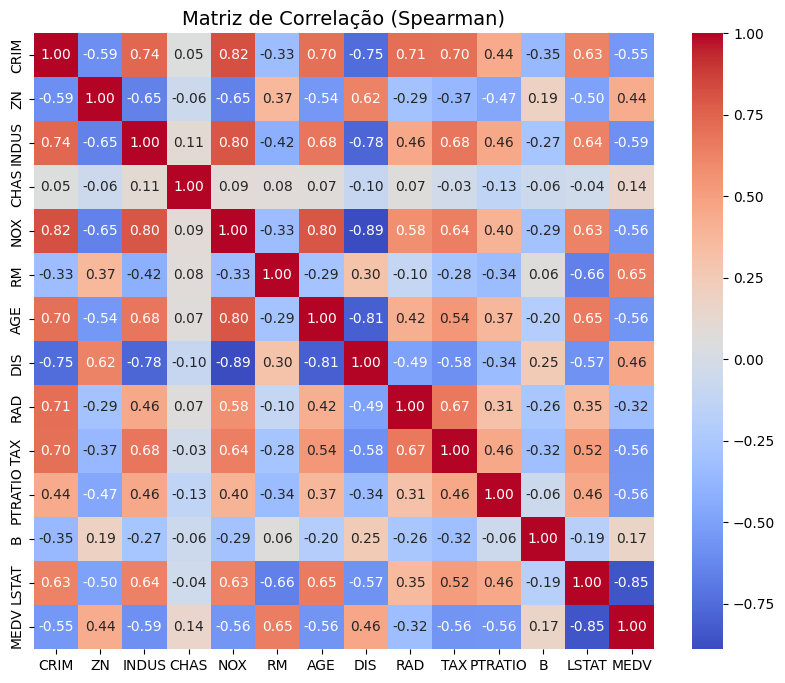

In [12]:
# calcula a matriz de correlação de Spearman
corr_matrix = df_train.corr(method='spearman')

# plota o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # mostra os valores numéricos nas células
    fmt=".2f",         # formato dos números
    cmap="coolwarm",   # esquema de cores
    cbar=True          # barra lateral de cores
)
plt.title("Matriz de Correlação (Spearman)", fontsize=14)
plt.show()

In [13]:
# Correlação entre as features e variável alvo
round(corr_matrix.sort_values(by='MEDV', ascending=False)['MEDV'],2)

MEDV       1.00
RM         0.65
DIS        0.46
ZN         0.44
B          0.17
CHAS       0.14
RAD       -0.32
CRIM      -0.55
PTRATIO   -0.56
NOX       -0.56
AGE       -0.56
TAX       -0.56
INDUS     -0.59
LSTAT     -0.85
Name: MEDV, dtype: float64

In [14]:
# Correlação entre as features e variável alvo (Valor Absoluto)
round(abs(corr_matrix).sort_values(by='MEDV', ascending=False)['MEDV'],2)

MEDV       1.00
LSTAT      0.85
RM         0.65
INDUS      0.59
TAX        0.56
AGE        0.56
NOX        0.56
PTRATIO    0.56
CRIM       0.55
DIS        0.46
ZN         0.44
RAD        0.32
B          0.17
CHAS       0.14
Name: MEDV, dtype: float64

### Analizando a variável alvo (MEDV) 

Text(0.5, 1.0, 'Histograma da variável alvo (MEDV)')

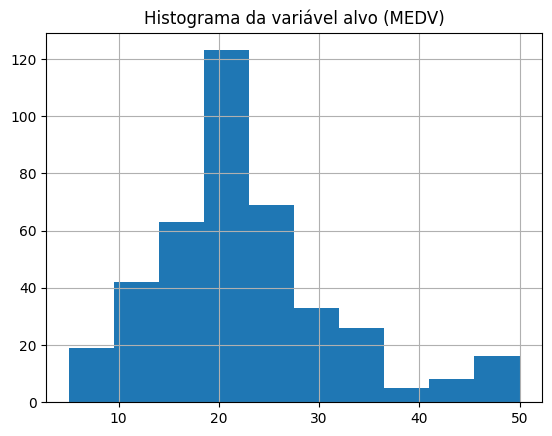

In [15]:
# Distribuição da variável alvo (MEDV)
df_train['MEDV'].hist(bins=10)
plt.title('Histograma da variável alvo (MEDV)')

Como podemos ver, a várivel alvo segue uma distribuição aproximadamente normal, porém podemos observar uma cauda à direita para valores maiores do que 37, o que pode indicar a presença de outliers nos dados.

Text(0.5, 1.0, 'Box plot da variável alvo (MEDV)')

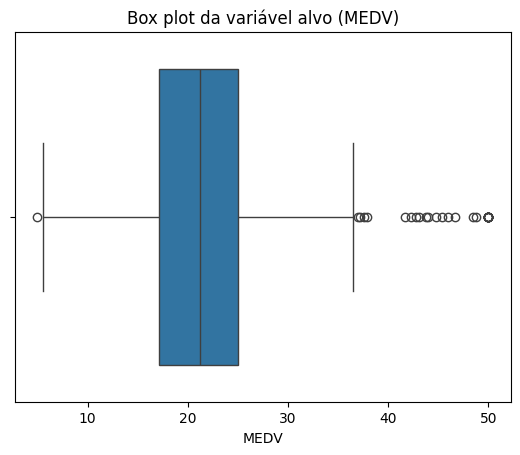

In [16]:
# Box Plot da variável alvo
sns.boxplot(df_train,x='MEDV')
plt.title('Box plot da variável alvo (MEDV)')

### Indentificando variáveis mais correlacionadas

In [17]:
def Correlated_Variables(df, threshold=0.6, method='spearman'):
    # calcula matriz de correlação
    cor_mat = df.corr(method=method)
    
    # pega apenas triângulo superior (sem diagonal)
    mask = np.triu(np.ones(cor_mat.shape), k=1).astype(bool)

    # transforma em série com pares
    cor_series = cor_mat.where(mask).stack()
    
    # filtra por threshold
    correlated_pairs = cor_series[cor_series.abs() >= threshold]
    
    # retorna um dataframe com as colunas Col1, Col2 e Correlação
    return pd.DataFrame([[i, j, round(corr,2)] for (i, j), corr in correlated_pairs.items()],columns = ['Col1','Col2','Correlação'])

# Identificamos as váriveis que apresentam uma correlação (Spearman) superior a 0.7
correlated_pairs = Correlated_Variables(df_train.drop(columns='MEDV'), threshold=0.7)
correlated_pairs


,Col1,Col2,Correlação
0,CRIM,INDUS,0.74
1,CRIM,NOX,0.82
2,CRIM,AGE,0.70
3,CRIM,DIS,-0.75
4,CRIM,RAD,0.71
5,CRIM,TAX,0.70
6,INDUS,NOX,0.80
7,INDUS,DIS,-0.78
8,NOX,AGE,0.80
9,NOX,DIS,-0.89


### Identificando variáveis altamente concentradas

In [18]:
# Função que identifica features (colunas) que apresentam concentração de valores acima de um limiar especificado (threshold).
# Exemplo: se uma coluna tem 80% de seus valores iguais, com threshold=0.7 ela será detectada.
def Constant_Filter(df, threshold):
    return [col for col in df.columns if df[col].value_counts(normalize=True).max() >= threshold    ]

# Aqui procuramos colunas onde pelo menos 70% (threshold=0.7) dos valores são iguais
concentrated_variables = Constant_Filter(df_train.drop(columns='MEDV'), threshold=0.7)

# Lista de variáveis que atendem ao critério de concentração
concentrated_variables


['ZN', 'CHAS']

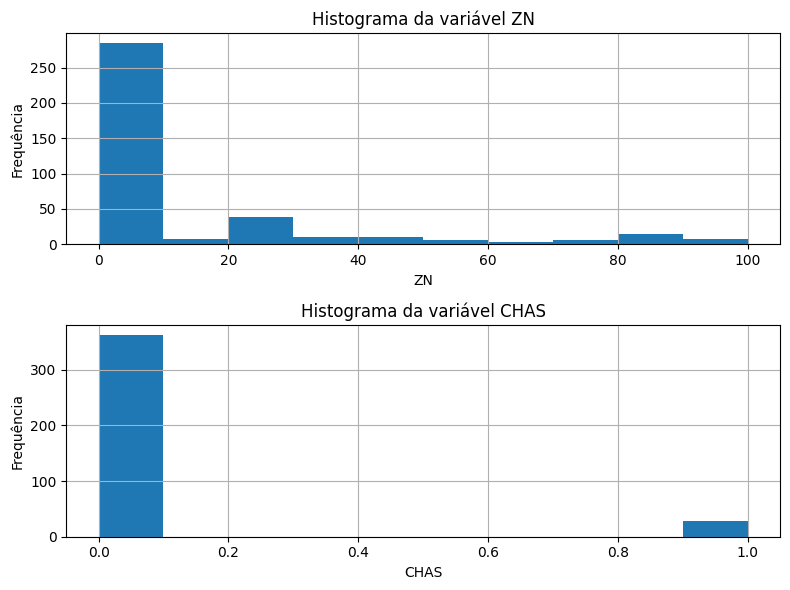

In [19]:
# Cria uma figura com 2 linhas e 1 coluna de subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# Para cada variável "concentrada", plota o histograma no respectivo eixo
for col, ax in zip(concentrated_variables, axs.flatten()):
    df_train[col].hist(bins=10, ax=ax)
    ax.set_title(f'Histograma da variável {col}')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")

# Ajusta o layout para evitar sobreposição de títulos/labels
plt.tight_layout()
plt.show()


como podemos observar ambas as váriaveis são concetradas no primeiro bin

### Identificação de Outliers Utilizando Isolation Forest

In [20]:
# Nome da variável alvo (coluna que queremos prever)
y_col = 'MEDV'

# Conjunto de treino sem a coluna alvo (somente variáveis independentes)
X_train = df_train.drop(columns=[y_col])

# Pipeline de pré-processamento:
# 1. SimpleImputer(strategy='median') → preenche valores faltantes com a mediana de cada coluna
# 2. StandardScaler() → padroniza as variáveis (média = 0, desvio padrão = 1)
pipe = make_pipeline(
    SimpleImputer(strategy='median'), 
    StandardScaler()
    )

# Aplica o pipeline de pré-processamento aos dados de treino
X_train_scaled = pipe.fit_transform(X_train)

# Modelo de detecção de outliers: Isolation Forest
iforest = IsolationForest(
    n_estimators=200,     # número de árvores da floresta
    max_samples='auto',   # tamanho da amostra usada em cada árvore (auto = min(256, n_samples))
    random_state=42,      # reprodutibilidade
    contamination='auto'  # proporção estimada de outliers (auto = baseado nos dados)
)

# Treina o modelo e faz a predição:
# Cada amostra recebe:
#   1  → normal
#  -1  → outlier
prediction = iforest.fit_predict(X_train_scaled)

# Conta quantos outliers (-1) e quantos pontos normais (1) foram detectados
n_outliers = np.sum(prediction == -1)
n_normals = np.sum(prediction == 1)

print("Number of outliers detected:", n_outliers)
print("Number of normal samples detected:", n_normals)

# Separa os dados de treino em dois DataFrames:
# normal_data → somente as amostras normais
# outliers    → somente as amostras consideradas anômalas
normal_data = df_train[prediction == 1]
outliers = df_train[prediction == -1]

# Exibe os outliers encontrados
outliers


Number of outliers detected: 60
Number of normal samples detected: 344


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
405,67.92080,0.0,18.10,0.0,0.6930,5.683,100.0,1.4254,24,666,20.2,384.97,22.98,5.0
489,0.18337,0.0,27.74,0.0,0.6090,5.414,98.3,1.7554,4,711,20.1,344.05,23.97,7.0
155,3.53501,0.0,19.58,1.0,0.8710,6.152,NaN,1.7455,5,403,14.7,88.01,15.02,15.6
126,0.38735,0.0,25.65,0.0,0.5810,5.613,NaN,1.7572,2,188,19.1,359.29,27.26,15.7
200,0.01778,95.0,1.47,0.0,0.4030,7.135,13.9,7.6534,3,402,17.0,384.30,4.45,32.9
197,0.04666,80.0,1.52,0.0,0.4040,7.107,36.6,7.3090,2,329,12.6,354.31,8.61,30.3
196,NaN,80.0,1.52,0.0,0.4040,7.287,34.1,7.3090,2,329,12.6,396.90,4.08,33.3
102,0.22876,0.0,8.56,0.0,0.5200,6.405,85.4,2.7147,5,384,20.9,70.80,10.63,18.6
54,0.01360,75.0,4.00,0.0,0.4100,5.888,47.6,7.3197,3,469,21.1,396.90,14.80,18.9
202,0.02177,82.5,2.03,0.0,0.4150,7.610,15.7,6.2700,2,348,14.7,395.38,3.11,42.3


Text(0.5, 1.0, 'Histograma da variável alvo (MEDV) no conjunto de outliers')

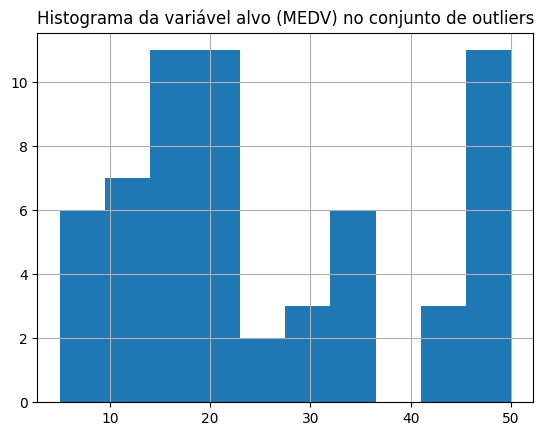

In [21]:
# Distribuição da variável alvo (MEDV)
outliers['MEDV'].hist(bins=10)
plt.title('Histograma da variável alvo (MEDV) no conjunto de outliers')

Text(0.5, 1.0, 'Histograma da variável alvo (MEDV) no conjunto sem outliers')

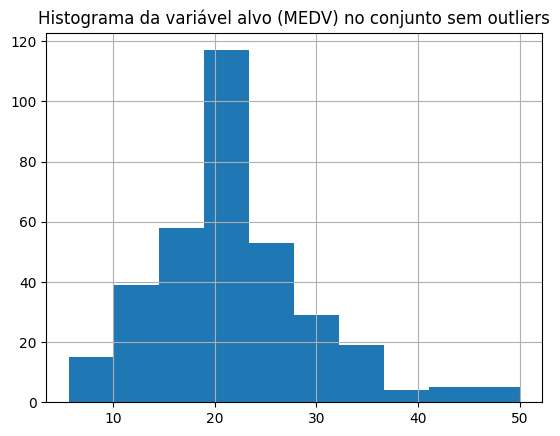

In [22]:
# Distribuição da variável alvo (MEDV)
normal_data['MEDV'].hist(bins=10)
plt.title('Histograma da variável alvo (MEDV) no conjunto sem outliers')

In [23]:
# Salvando os dadasets de treino e teste. Optamos por salvar os dados de treino após a remoção de outliers
normal_data.to_csv('./Data/train.csv', index=False)
df_test.to_csv('./Data/test.csv')